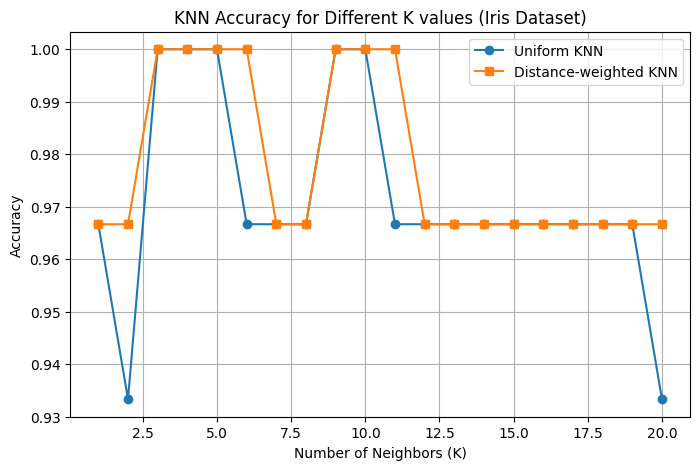

Best K (Uniform weights): 3, Accuracy = 1.000
Best K (Distance weights): 3, Accuracy = 1.000


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

k_values = range(1, 21)

uniform_acc = []
distance_acc = []

for k in k_values:
    knn_uniform = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    knn_uniform.fit(X_train, y_train)
    y_pred_uniform = knn_uniform.predict(X_test)
    uniform_acc.append(accuracy_score(y_test, y_pred_uniform))
    
    knn_distance = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_distance.fit(X_train, y_train)
    y_pred_distance = knn_distance.predict(X_test)
    distance_acc.append(accuracy_score(y_test, y_pred_distance))

plt.figure(figsize=(8, 5))
plt.plot(k_values, uniform_acc, marker='o', label="Uniform KNN")
plt.plot(k_values, distance_acc, marker='s', label="Distance-weighted KNN")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K values (Iris Dataset)")
plt.legend()
plt.grid(True)
plt.show()

best_uniform_k = k_values[np.argmax(uniform_acc)]
best_distance_k = k_values[np.argmax(distance_acc)]

print(f"Best K (Uniform weights): {best_uniform_k}, Accuracy = {max(uniform_acc):.3f}")
print(f"Best K (Distance weights): {best_distance_k}, Accuracy = {max(distance_acc):.3f}")
